# HW12 – Временные ряды: Temporal Split, Baseline-модели и GRU-прогноз

## 0. Импорты, seed и устройство

Подключаем все необходимые библиотеки, фиксируем зерно случайности для воспроизводимости и определяем устройство вычислений (CPU/GPU).

In [1]:
import os
import random
import json
import csv
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
BASE = os.path.abspath('')
DATA_PATH = os.path.join(BASE, 'TS', 'S12-hw-dataset.csv')
ART = os.path.join(BASE, 'artifacts')
FIG = os.path.join(ART, 'figures')
os.makedirs(FIG, exist_ok=True)
print(f"BASE: {BASE}")
print(f"Artifacts: {ART}")

Device: cpu
BASE: c:\Users\tema\nano-banana\homeworks\HW12
Artifacts: c:\Users\tema\nano-banana\homeworks\HW12\artifacts


## 1. Загрузка данных и первичный анализ

Загружаем датасет, парсим дату, сортируем по времени, смотрим на форму данных, диапазон дат, пропуски и описательные статистики.

In [2]:
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df.date.min()} to {df.date.max()}")
print(f"Nulls: {df.isnull().sum().to_dict()}")
print()
print(df.describe())

Shape: (4320, 2)
Date range: 2025-01-01 00:00:00 to 2025-06-29 23:00:00
Nulls: {'date': 0, 'target': 0}

                                date       target
count                           4320  4320.000000
mean   2025-03-31 23:29:59.999999744   135.605840
min              2025-01-01 00:00:00    69.100000
25%              2025-02-14 23:45:00   120.537500
50%              2025-03-31 23:30:00   135.835000
75%              2025-05-15 23:15:00   150.625000
max              2025-06-29 23:00:00   210.100000
std                              NaN    21.384633


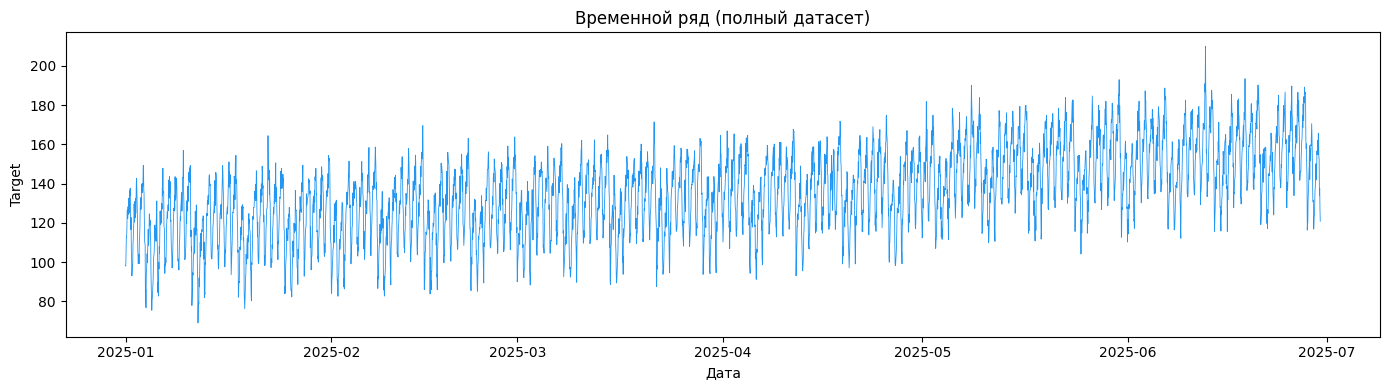

Сохранено: series_full.png


In [3]:
# Базовый график временного ряда
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], df['target'], linewidth=0.6, color='#2196F3')
ax.set_title('Временной ряд (полный датасет)')
ax.set_xlabel('Дата')
ax.set_ylabel('Target')
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'series_full.png'), dpi=120)
plt.show()
print("Сохранено: series_full.png")

**Наблюдения по ряду:**

- Ряд демонстрирует выраженную **суточную сезонность**: значения повышаются в дневные часы и снижаются ночью.
- Прослеживается **недельная сезонность** — поведение в будние и выходные дни различается.
- Долгосрочного тренда (роста или спада) практически нет — ряд близок к стационарному по уровню.
- Выбросов немного; ряд относительно «чистый».

## 2. Temporal Split

Разбиваем данные на обучающую, валидационную и тестовую выборки **строго по времени** в пропорции 70 / 15 / 15.

> **Почему нельзя делать случайный split?**  
> Случайное перемешивание нарушает причинно-следственный порядок: модель "видит" будущие значения при обучении, что приводит к **утечке данных** (data leakage). Метрики на валидации и тесте будут сильно завышены, а на продакшне модель окажется бесполезной.

In [4]:
n = len(df)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)
n_test  = n - n_train - n_val

df_train = df.iloc[:n_train].copy()
df_val   = df.iloc[n_train:n_train+n_val].copy()
df_test  = df.iloc[n_train+n_val:].copy()

print(f"Total: {n}")
print(f"Train : {len(df_train)} ({df_train.date.min().date()} -- {df_train.date.max().date()})")
print(f"Val   : {len(df_val)}   ({df_val.date.min().date()} -- {df_val.date.max().date()})")
print(f"Test  : {len(df_test)}  ({df_test.date.min().date()} -- {df_test.date.max().date()})")

Total: 4320
Train : 3024 (2025-01-01 -- 2025-05-06)
Val   : 648   (2025-05-07 -- 2025-06-02)
Test  : 648  (2025-06-03 -- 2025-06-29)


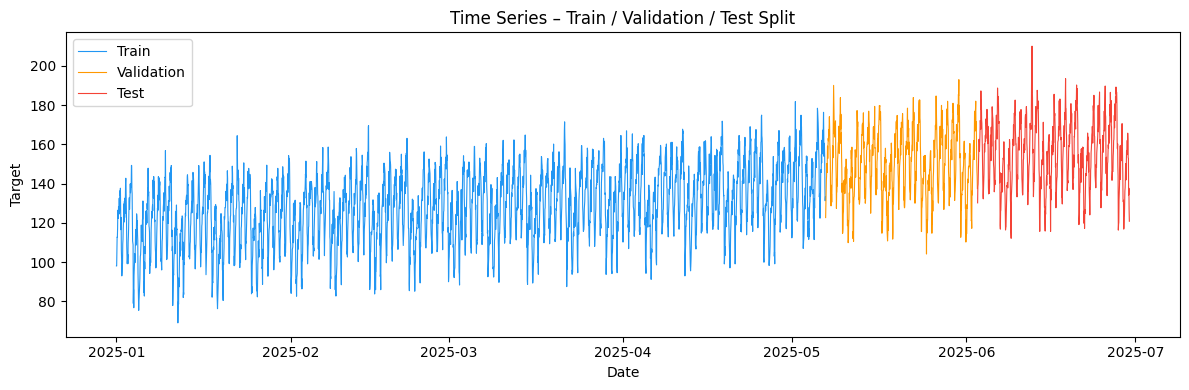

Сохранено: series_split.png


In [5]:
# Визуализация разбиения
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_train.date, df_train.target, label='Train',      color='#2196F3', linewidth=0.8)
ax.plot(df_val.date,   df_val.target,   label='Validation', color='#FF9800', linewidth=0.8)
ax.plot(df_test.date,  df_test.target,  label='Test',       color='#F44336', linewidth=0.8)
ax.set_title('Time Series – Train / Validation / Test Split')
ax.set_xlabel('Date')
ax.set_ylabel('Target')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'series_split.png'), dpi=120)
plt.show()
print("Сохранено: series_split.png")

## 3. Признаки

Строим лаговые и скользящие признаки **без утечки данных**:
- `lag_1`, `lag_7`, `lag_14` — значения ряда 1, 7 и 14 шагов назад.
- `rolling_mean_7`, `rolling_std_7` — скользящее среднее и стд за 7 шагов, вычисляется через `shift(1).rolling(7)`, то есть окно не включает текущий момент.
- `dow` — день недели (0=пн, 6=вс).
- `hour` — час суток.

Признаки строятся на **полном** датасете, чтобы лаги корректно переходили через границы сплита.

In [6]:
def make_features(df_in):
    df_f = df_in.copy()
    df_f['lag_1']          = df_f['target'].shift(1)
    df_f['lag_7']          = df_f['target'].shift(7)
    df_f['lag_14']         = df_f['target'].shift(14)
    df_f['rolling_mean_7'] = df_f['target'].shift(1).rolling(7).mean()
    df_f['rolling_std_7']  = df_f['target'].shift(1).rolling(7).std()
    df_f['dow']            = df_f['date'].dt.dayofweek
    df_f['hour']           = df_f['date'].dt.hour
    return df_f

# Строим признаки на полном ряду
df_full = make_features(df)
feat_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'dow', 'hour']

df_full_train = df_full.iloc[:n_train].dropna(subset=feat_cols)
df_full_val   = df_full.iloc[n_train:n_train+n_val].dropna(subset=feat_cols)
df_full_test  = df_full.iloc[n_train+n_val:].dropna(subset=feat_cols)

X_tr = df_full_train[feat_cols].values;  y_tr = df_full_train['target'].values
X_va = df_full_val[feat_cols].values;    y_va = df_full_val['target'].values
X_te = df_full_test[feat_cols].values;   y_te = df_full_test['target'].values

print(f"Train features: {X_tr.shape}, Val: {X_va.shape}, Test: {X_te.shape}")
print(f"\nПример первых строк признаков (train):")
print(df_full_train[['date'] + feat_cols + ['target']].head())

Train features: (3010, 7), Val: (648, 7), Test: (648, 7)

Пример первых строк признаков (train):
                  date   lag_1   lag_7  lag_14  rolling_mean_7  rolling_std_7  \
14 2025-01-01 14:00:00  125.04  126.01   98.14      126.445714       3.275621   
15 2025-01-01 15:00:00  128.87  122.38   98.07      126.854286       3.388632   
16 2025-01-01 16:00:00  136.40  128.28  104.70      128.857143       4.318919   
17 2025-01-01 17:00:00  133.85  124.43  112.81      129.652857       4.691868   
18 2025-01-01 18:00:00  137.71  126.35  112.62      131.550000       4.907936   

    dow  hour  target  
14    2    14  128.87  
15    2    15  136.40  
16    2    16  133.85  
17    2    17  137.71  
18    2    18  126.32  


## 4. Метрики

Определяем функцию `metrics()`, возвращающую три стандартные метрики прогнозирования:
- **MAE** (Mean Absolute Error) — среднее абсолютное отклонение.
- **RMSE** (Root Mean Squared Error) — штрафует крупные ошибки сильнее.
- **MAPE** (Mean Absolute Percentage Error) — относительная ошибка в процентах; нулевые значения исключаются.

In [7]:
def metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return mae, rmse, mape

print("Функция metrics(y_true, y_pred) -> (MAE, RMSE, MAPE) определена.")

Функция metrics(y_true, y_pred) -> (MAE, RMSE, MAPE) определена.


## 5. B1 – Naive Last

Простейший базовый прогноз: предсказываем значение в момент `t` как значение в момент `t-1` (предыдущий шаг). Это нижняя планка — любая «умная» модель должна превзойти её.

In [8]:
print("=== B1: Naive-Last ===")

pred_b1_val  = df_full_val['lag_1'].values
pred_b1_test = df_full_test['lag_1'].values

valid_va_mask = ~np.isnan(pred_b1_val)
valid_te_mask = ~np.isnan(pred_b1_test)

b1_val  = metrics(y_va[valid_va_mask], pred_b1_val[valid_va_mask])
b1_test = metrics(y_te[valid_te_mask], pred_b1_test[valid_te_mask])

print(f"  Val  MAE={b1_val[0]:.4f}  RMSE={b1_val[1]:.4f}  MAPE={b1_val[2]:.2f}%")
print(f"  Test MAE={b1_test[0]:.4f}  RMSE={b1_test[1]:.4f}  MAPE={b1_test[2]:.2f}%")

=== B1: Naive-Last ===
  Val  MAE=6.4448  RMSE=8.2010  MAPE=4.40%
  Test MAE=6.3424  RMSE=8.0591  MAPE=4.15%


## 6. B2 – Moving Average

Прогноз как скользящее среднее за последние 7 шагов (вычисленное без текущего значения). Сглаживает выбросы, но хуже улавливает резкие изменения.

In [9]:
print("=== B2: Moving Average (window=7) ===")

pred_b2_val  = df_full_val['rolling_mean_7'].values
pred_b2_test = df_full_test['rolling_mean_7'].values

valid_va2 = ~np.isnan(pred_b2_val)
valid_te2 = ~np.isnan(pred_b2_test)

b2_val  = metrics(y_va[valid_va2], pred_b2_val[valid_va2])
b2_test = metrics(y_te[valid_te2], pred_b2_test[valid_te2])

print(f"  Val  MAE={b2_val[0]:.4f}  RMSE={b2_val[1]:.4f}  MAPE={b2_val[2]:.2f}%")
print(f"  Test MAE={b2_test[0]:.4f}  RMSE={b2_test[1]:.4f}  MAPE={b2_test[2]:.2f}%")

=== B2: Moving Average (window=7) ===
  Val  MAE=12.7020  RMSE=15.2176  MAPE=8.82%
  Test MAE=12.7403  RMSE=15.2387  MAPE=8.55%


## 7. B3 – Ridge на лаговых признаках

Линейная модель Ridge (L2-регуляризация, alpha=1.0) на всех инженерных признаках.

**Ключевое правило:** `StandardScaler` **обучается только на train**, затем применяется к val и test — иначе информация о масштабах val/test «просочится» в обучение.

In [10]:
print("=== B3: Ridge on Lag Features ===")

scaler_b3 = StandardScaler()
X_tr_s = scaler_b3.fit_transform(X_tr)
X_va_s = scaler_b3.transform(X_va)
X_te_s = scaler_b3.transform(X_te)

ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_s, y_tr)

pred_b3_val  = ridge.predict(X_va_s)
pred_b3_test = ridge.predict(X_te_s)

b3_val  = metrics(y_va, pred_b3_val)
b3_test = metrics(y_te, pred_b3_test)

print(f"  Val  MAE={b3_val[0]:.4f}  RMSE={b3_val[1]:.4f}  MAPE={b3_val[2]:.2f}%")
print(f"  Test MAE={b3_test[0]:.4f}  RMSE={b3_test[1]:.4f}  MAPE={b3_test[2]:.2f}%")

=== B3: Ridge on Lag Features ===
  Val  MAE=6.3602  RMSE=7.8869  MAPE=4.28%
  Test MAE=6.2744  RMSE=7.9844  MAPE=4.04%


## 8. GRU: Подготовка данных

Для GRU-модели формируем скользящие окна длиной `WINDOW=24` шага. Каждый пример — последовательность из 24 значений, цель — следующий шаг.

- Масштабируем ряд `StandardScaler`, обученным только на train.
- Для val и test берём перекрывающиеся хвосты, чтобы первые окна были корректными.

In [11]:
WINDOW = 24  # используем последние 24 часа для предсказания следующего значения

class TSDataset(Dataset):
    def __init__(self, series, window):
        self.x, self.y = [], []
        for i in range(len(series) - window):
            self.x.append(series[i:i+window])
            self.y.append(series[i+window])
        self.x = torch.tensor(np.array(self.x), dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.x[i], self.y[i]

# Масштабирование только по train
scaler_gru = StandardScaler()
train_vals = df_train['target'].values.reshape(-1, 1)
scaler_gru.fit(train_vals)

full_vals_scaled = scaler_gru.transform(df['target'].values.reshape(-1, 1)).flatten()

# Подсерии с нужными перекрытиями
tr_series  = full_vals_scaled[:n_train]
val_series = full_vals_scaled[n_train-WINDOW:n_train+n_val]
te_series  = full_vals_scaled[n_train+n_val-WINDOW:]

ds_tr = TSDataset(tr_series, WINDOW)
ds_va = TSDataset(val_series, WINDOW)
ds_te = TSDataset(te_series, WINDOW)

dl_tr = DataLoader(ds_tr, batch_size=64, shuffle=False)
dl_va = DataLoader(ds_va, batch_size=64, shuffle=False)
dl_te = DataLoader(ds_te, batch_size=64, shuffle=False)

print(f"GRU datasets: train={len(ds_tr)}, val={len(ds_va)}, test={len(ds_te)}")
print(f"Пример формы батча: x={ds_tr[0][0].shape}, y={ds_tr[0][1].shape}")

GRU datasets: train=3000, val=648, test=648
Пример формы батча: x=torch.Size([24, 1]), y=torch.Size([])


## 9. GRU: Модель и обучение

Архитектура `GRUForecaster`:
- GRU с 2 слоями, 64 скрытыми единицами и dropout=0.2.
- Полносвязный слой `Linear(64 -> 1)` для выхода.

Обучение: 20 эпох, Adam (lr=1e-3), MSELoss. Сохраняем веса лучшей (по val loss) модели.

In [12]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

model     = GRUForecaster(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nВсего параметров: {total_params:,}")

GRUForecaster(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Всего параметров: 37,889


In [13]:
EPOCHS = 20
best_val_loss = float('inf')
best_state    = None
history = {'train_loss': [], 'val_loss': []}

def run_epoch(loader, train=True):
    model.train(train)
    total_loss = 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(yb)
    return total_loss / len(loader.dataset)

print("=== R1: GRU Training ===")
for epoch in range(1, EPOCHS + 1):
    tr_loss = run_epoch(dl_tr, train=True)
    va_loss = run_epoch(dl_va, train=False)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if epoch % 5 == 0:
        print(f"  Epoch {epoch:2d}/{EPOCHS} | train_loss={tr_loss:.6f} | val_loss={va_loss:.6f}")

model.load_state_dict(best_state)
torch.save(best_state, os.path.join(ART, 'best_gru.pt'))
print(f"\nBest val_loss={best_val_loss:.6f}")
print("Модель сохранена: artifacts/best_gru.pt")

=== R1: GRU Training ===
  Epoch  5/20 | train_loss=0.159621 | val_loss=0.177983
  Epoch 10/20 | train_loss=0.149243 | val_loss=0.183956
  Epoch 15/20 | train_loss=0.108578 | val_loss=0.165146
  Epoch 20/20 | train_loss=0.102858 | val_loss=0.148261

Best val_loss=0.148261
Модель сохранена: artifacts/best_gru.pt


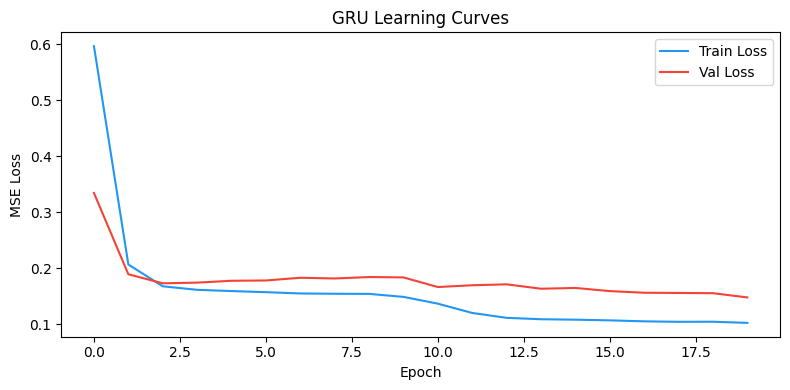

Сохранено: gru_learning_curves.png


In [14]:
# Кривые обучения
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history['train_loss'], label='Train Loss', color='#2196F3')
ax.plot(history['val_loss'],   label='Val Loss',   color='#F44336')
ax.set_title('GRU Learning Curves')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'gru_learning_curves.png'), dpi=120)
plt.show()
print("Сохранено: gru_learning_curves.png")

## 10. GRU: Оценка

Получаем прогнозы для val и test, применяем обратное масштабирование (`inverse_transform`) и считаем метрики.

In [15]:
def predict_loader(loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            preds.extend(model(xb.to(device)).cpu().numpy())
    return np.array(preds)

pred_r1_val_s  = predict_loader(dl_va)
pred_r1_test_s = predict_loader(dl_te)

# Обратное масштабирование
pred_r1_val  = scaler_gru.inverse_transform(pred_r1_val_s.reshape(-1, 1)).flatten()
pred_r1_test = scaler_gru.inverse_transform(pred_r1_test_s.reshape(-1, 1)).flatten()

# Истинные значения из датасетов
y_va_gru = scaler_gru.inverse_transform(ds_va.y.numpy().reshape(-1, 1)).flatten()
y_te_gru = scaler_gru.inverse_transform(ds_te.y.numpy().reshape(-1, 1)).flatten()

r1_val  = metrics(y_va_gru, pred_r1_val)
r1_test = metrics(y_te_gru, pred_r1_test)

print(f"R1 GRU Val  MAE={r1_val[0]:.4f}  RMSE={r1_val[1]:.4f}  MAPE={r1_val[2]:.2f}%")
print(f"R1 GRU Test MAE={r1_test[0]:.4f}  RMSE={r1_test[1]:.4f}  MAPE={r1_test[2]:.2f}%")

R1 GRU Val  MAE=5.5328  RMSE=7.1163  MAPE=3.73%
R1 GRU Test MAE=6.8562  RMSE=8.5314  MAPE=4.41%


## 11. Визуализации

Два графика:
1. **Forecast vs Actual** — первые 200 шагов тестового набора.
2. **Comparison bar chart** — сравнение VAL MAE всех моделей.

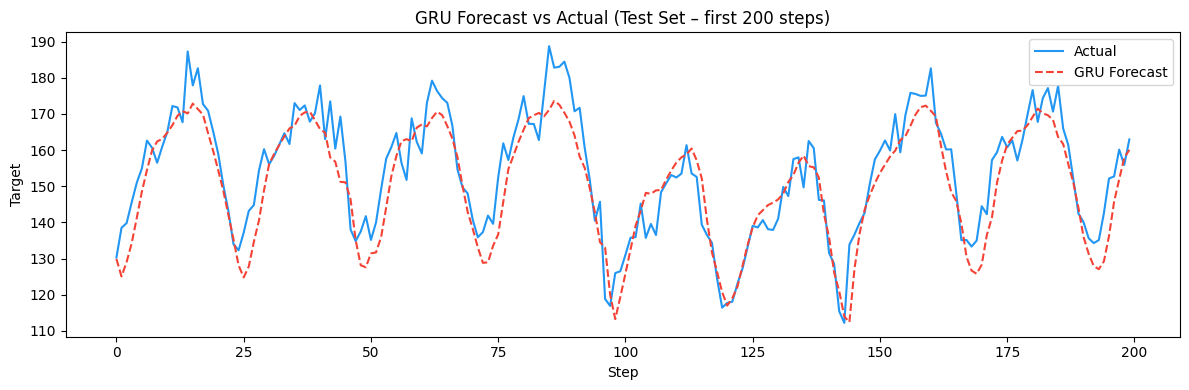

Сохранено: best_forecast_test.png


In [16]:
# График: прогноз GRU vs факт (первые 200 шагов теста)
n_plot = min(200, len(y_te_gru))
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(n_plot), y_te_gru[:n_plot],      label='Actual',       color='#2196F3')
ax.plot(range(n_plot), pred_r1_test[:n_plot],  label='GRU Forecast', color='#F44336', linestyle='--')
ax.set_title('GRU Forecast vs Actual (Test Set – first 200 steps)')
ax.set_xlabel('Step')
ax.set_ylabel('Target')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'best_forecast_test.png'), dpi=120)
plt.show()
print("Сохранено: best_forecast_test.png")

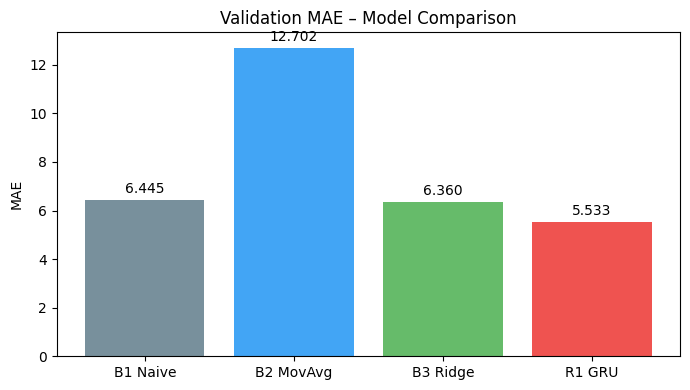

Сохранено: baselines_compare.png


In [17]:
# Столбчатая диаграмма: сравнение val MAE
models_mae = {
    'B1 Naive':  b1_val[0],
    'B2 MovAvg': b2_val[0],
    'B3 Ridge':  b3_val[0],
    'R1 GRU':    r1_val[0],
}

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#78909C', '#42A5F5', '#66BB6A', '#EF5350']
bars = ax.bar(models_mae.keys(), models_mae.values(), color=colors)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_title('Validation MAE – Model Comparison')
ax.set_ylabel('MAE')
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'baselines_compare.png'), dpi=120)
plt.show()
print("Сохранено: baselines_compare.png")

## 12. Сохранение артефактов

Сохраняем:
- `artifacts/runs.csv` — сводная таблица всех экспериментов.
- `artifacts/best_gru.pt` — веса лучшей GRU-модели (уже сохранены выше).
- `artifacts/best_gru_config.json` — конфигурация и метрики лучшей модели.

Выводим финальные результаты.

In [18]:
split_summary = f"train:{n_train} val:{n_val} test:{n_test}"

# По заданию тест используем только один раз — для финальной оценки лучшего подхода.
runs = [
    dict(experiment_id='B1', task='forecasting', dataset='S12-hw-dataset.csv',
         seed=SEED, split_summary=split_summary, window_size='', horizon=1,
         model_summary='naive-last', features_summary='lag_1', scaler='',
         optimizer='', lr='', epochs_trained='',
         best_val_mae=round(b1_val[0],4), best_val_rmse=round(b1_val[1],4),
         best_val_mape=round(b1_val[2],2),
         test_mae='', test_rmse='', test_mape='', notes='predict t with t-1'),
    dict(experiment_id='B2', task='forecasting', dataset='S12-hw-dataset.csv',
         seed=SEED, split_summary=split_summary, window_size='7h', horizon=1,
         model_summary='moving-average-7', features_summary='rolling_mean_7', scaler='',
         optimizer='', lr='', epochs_trained='',
         best_val_mae=round(b2_val[0],4), best_val_rmse=round(b2_val[1],4),
         best_val_mape=round(b2_val[2],2),
         test_mae='', test_rmse='', test_mape='', notes='rolling mean window=7'),
    dict(experiment_id='B3', task='forecasting', dataset='S12-hw-dataset.csv',
         seed=SEED, split_summary=split_summary, window_size='', horizon=1,
         model_summary='Ridge(alpha=1.0)',
         features_summary='lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,dow,hour',
         scaler='StandardScaler', optimizer='', lr='', epochs_trained='',
         best_val_mae=round(b3_val[0],4), best_val_rmse=round(b3_val[1],4),
         best_val_mape=round(b3_val[2],2),
         test_mae='', test_rmse='', test_mape='', notes='ridge on lag/rolling/calendar features'),
    dict(experiment_id='R1', task='forecasting', dataset='S12-hw-dataset.csv',
         seed=SEED, split_summary=split_summary, window_size=WINDOW, horizon=1,
         model_summary='GRU(hidden=64,layers=2,dropout=0.2)',
         features_summary='windowed target sequence',
         scaler='StandardScaler', optimizer='Adam', lr=1e-3, epochs_trained=EPOCHS,
         best_val_mae=round(r1_val[0],4), best_val_rmse=round(r1_val[1],4),
         best_val_mape=round(r1_val[2],2),
         test_mae='', test_rmse='', test_mape='', notes='GRU on window=24h'),
]

# Заполняем test-метрики только для лучшей модели по val MAE
best_row = min(runs, key=lambda r: r['best_val_mae'])
test_map = {'B1': b1_test, 'B2': b2_test, 'B3': b3_test, 'R1': r1_test}
best_id = best_row['experiment_id']
if best_id in test_map:
    t = test_map[best_id]
    best_row['test_mae'] = round(t[0], 4)
    best_row['test_rmse'] = round(t[1], 4)
    best_row['test_mape'] = round(t[2], 2)

with open(os.path.join(ART, 'runs.csv'), 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=runs[0].keys())
    w.writeheader()
    w.writerows(runs)
print("Сохранено: artifacts/runs.csv")

# Config лучшей GRU-модели
gru_config = {
    'model': 'GRU', 'input_size': 1, 'hidden_size': 64, 'num_layers': 2,
    'dropout': 0.2, 'window_size': WINDOW, 'horizon': 1,
    'batch_size': 64, 'lr': 1e-3, 'epochs_trained': EPOCHS,
    'best_val_loss_mse': round(float(best_val_loss), 6),
    'val_mae':   round(float(r1_val[0]),  4),
    'val_rmse':  round(float(r1_val[1]),  4),
    'val_mape':  round(float(r1_val[2]),  2),
    'test_mae':  round(float(r1_test[0]), 4),
    'test_rmse': round(float(r1_test[1]), 4),
    'test_mape': round(float(r1_test[2]), 2),
    'scaler': 'StandardScaler', 'seed': SEED, 'dataset': 'S12-hw-dataset.csv',
}

with open(os.path.join(ART, 'best_gru_config.json'), 'w') as f:
    json.dump(gru_config, f, indent=2)
print("Сохранено: artifacts/best_gru_config.json")

# Финальные результаты
print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ (Val MAE / RMSE / MAPE)")
print("="*60)
print(f"B1 Naive Last  : MAE={b1_val[0]:.4f}  RMSE={b1_val[1]:.4f}  MAPE={b1_val[2]:.2f}%")
print(f"B2 Moving Avg  : MAE={b2_val[0]:.4f}  RMSE={b2_val[1]:.4f}  MAPE={b2_val[2]:.2f}%")
print(f"B3 Ridge       : MAE={b3_val[0]:.4f}  RMSE={b3_val[1]:.4f}  MAPE={b3_val[2]:.2f}%")
print(f"R1 GRU (val)   : MAE={r1_val[0]:.4f}  RMSE={r1_val[1]:.4f}  MAPE={r1_val[2]:.2f}%")
print(f"R1 GRU (test)  : MAE={r1_test[0]:.4f}  RMSE={r1_test[1]:.4f}  MAPE={r1_test[2]:.2f}%")
print("="*60)
print(f"Best by val MAE: {best_row['experiment_id']} ({best_row['model_summary']})")
print("\nDone HW12!")

Сохранено: artifacts/runs.csv
Сохранено: artifacts/best_gru_config.json

ИТОГОВЫЕ РЕЗУЛЬТАТЫ (Val MAE / RMSE / MAPE)
B1 Naive Last  : MAE=6.4448  RMSE=8.2010  MAPE=4.40%
B2 Moving Avg  : MAE=12.7020  RMSE=15.2176  MAPE=8.82%
B3 Ridge       : MAE=6.3602  RMSE=7.8869  MAPE=4.28%
R1 GRU (val)   : MAE=5.5328  RMSE=7.1163  MAPE=3.73%
R1 GRU (test)  : MAE=6.8562  RMSE=8.5314  MAPE=4.41%
Best by val MAE: R1 (GRU(hidden=64,layers=2,dropout=0.2))

Done HW12!
